In [1]:
import sys
sys.path.append("./Main/src")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from models_cl import CollectiveLearningModel

Alignment round 1
------------------------------------------------------------
Agent 26 (stubbornness: 0.999) --- (strength: 0.209) --- (neighbors: 49):
	Impacts before softmax: [0.00455565 0.00490665 0.00340853 1.00290553 0.00210073 0.00508801]
	Impacts after softmax: [0.12968343 0.12972896 0.12953476 0.3519349  0.12936546 0.12975249]
------------------------------------------------------------
Agent 11 (stubbornness: 0.886) --- (strength: 0.919) --- (neighbors: 49):
	Impacts before softmax: [0.53538707 1.38089796 0.40057589 0.45594189 0.24688098 0.59795037]
	Impacts after softmax: [0.14407932 0.33558487 0.12590817 0.13307579 0.10797049 0.15338135]
------------------------------------------------------------
Agent 33 (stubbornness: 0.957) --- (strength: 0.537) --- (neighbors: 49):
	Impacts before softmax: [0.19972132 1.15840908 0.14943123 0.17008501 0.09209672 0.22306   ]
	Impacts after softmax: [0.13419934 0.35002832 0.12761734 0.13028052 0.12050626 0.13736821]
----------------------

<Axes: title={'center': '50 agents, 1225 ties'}>

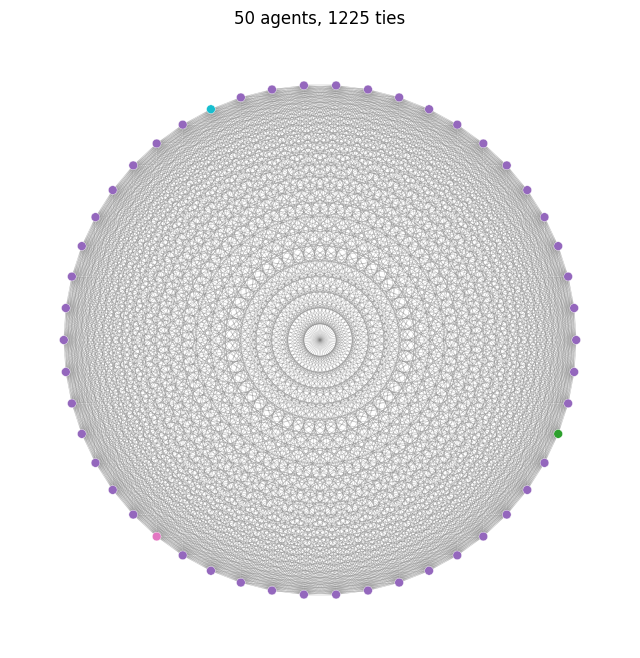

In [2]:
scenario = "consensus"

model = CollectiveLearningModel(
    n_agents=50,
    n_choices=6,
    network_type=scenario,
    alignment_max_time=10,
    consensus_threshold=1.0,
    seed=1
)

for agent in model.agents_list:
    agent.sampling = True

for i in range(1):
    model.step()

model.draw_network()

Alignment round 1
------------------------------------------------------------
Agent 6 (stubbornness: 0.750) --- (strength: 0.203) --- (neighbors: 1):
	Impacts before softmax: [0.12776876 0.75036467]
	Impacts after softmax: [0.34919128 0.65080872]
------------------------------------------------------------
Agent 7 (stubbornness: 0.981) --- (strength: 0.280) --- (neighbors: 1):
	Impacts before softmax: [0.00985912 0.9807372 ]
	Impacts after softmax: [0.27470552 0.72529448]
------------------------------------------------------------
Agent 2 (stubbornness: 0.550) --- (strength: 0.828) --- (neighbors: 1):
	Impacts before softmax: [0.23052769 0.54959369]
	Impacts after softmax: [0.42090339 0.57909661]
------------------------------------------------------------
Agent 3 (stubbornness: 0.754) --- (strength: 0.028) --- (neighbors: 1):
	Impacts before softmax: [0.87967043 0.        ]
	Impacts after softmax: [0.70675392 0.29324608]
------------------------------------------------------------
A

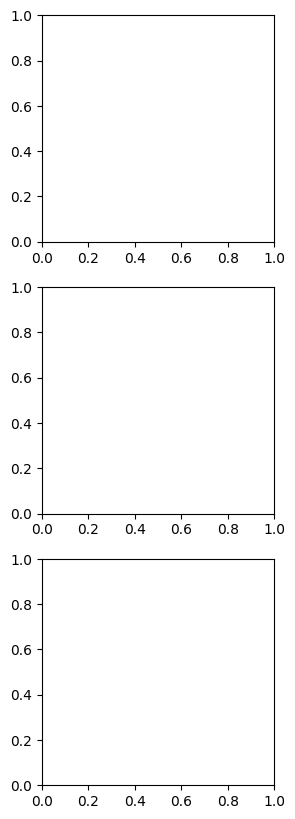

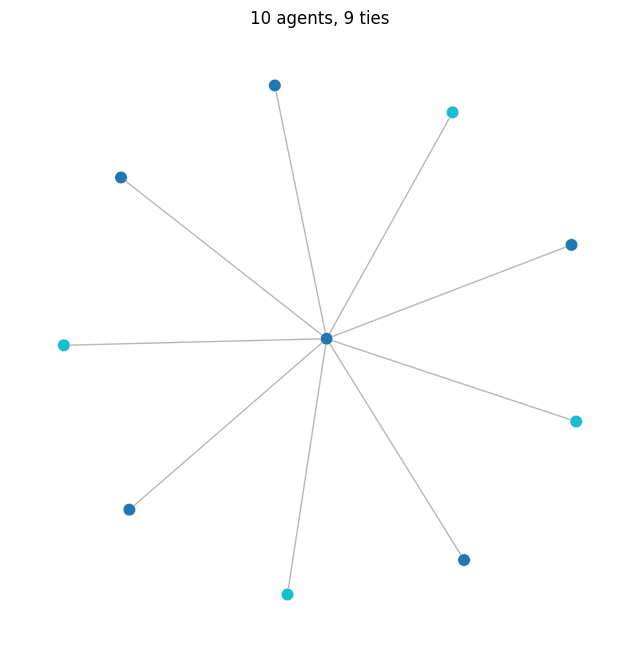

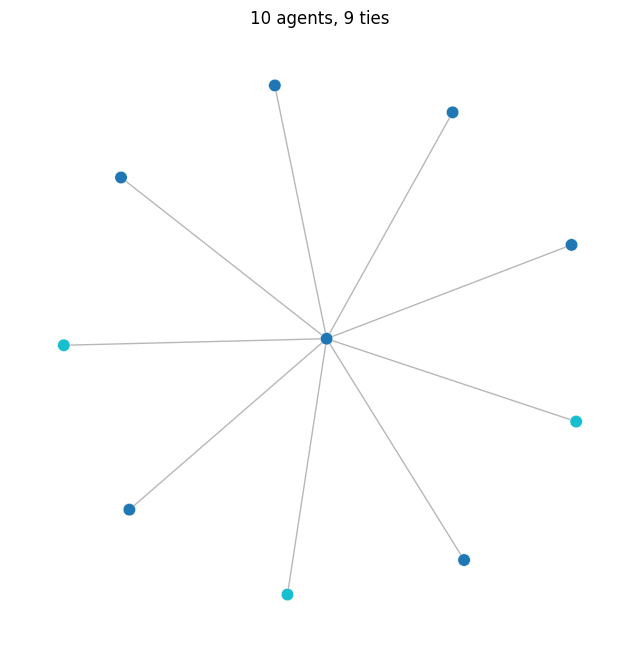

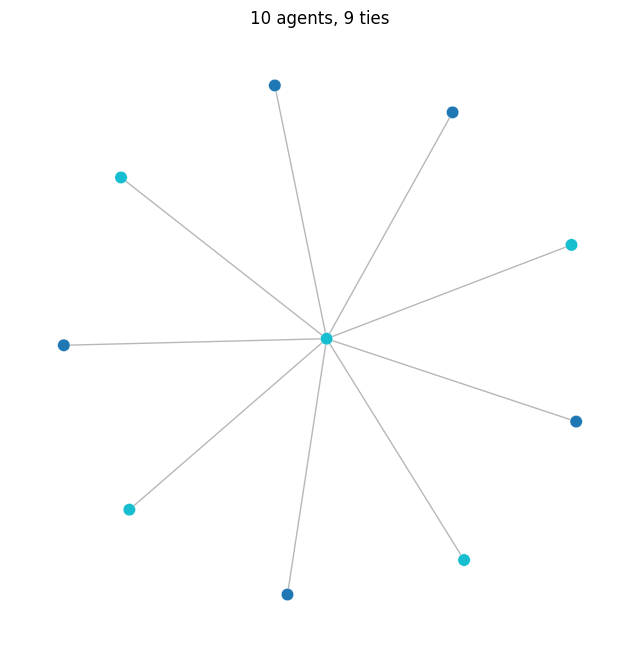

In [8]:
scenario = "consultative"

model = CollectiveLearningModel(
    n_agents=10,
    n_choices=2,
    network_type=scenario,
    alignment_max_time=10,
    consensus_threshold=1.0,
    seed=1
)

for agent in model.agents_list:
    agent.sampling = True

fig, ax = plt.subplots(3, 1, figsize=(3, 10))

for i in range(3):
    model.alignment_phase()
    model.draw_network()

In [4]:
agent = model.agents_list[4]
model.grid.get_neighbors(agent.node)

IndexError: list index out of range

In [ ]:
list_df = []
NUM_ALL_CYCLE_ROUNDS = 1
NUM_SIMULATIONS = 30
NUM_ALLIGNMENT_ROUNDS = 10

scenario = "consensus"

#-------------------------------
# CONSENSUS WITH TEMPERATURE 0
#-------------------------------
for seed in range(NUM_SIMULATIONS):
    model = CollectiveLearningModel(
        n_agents=50,
        n_choices=6,
        network_type=scenario,
        alignment_max_time=NUM_ALLIGNMENT_ROUNDS,
        consensus_threshold=1.0,
        seed=seed
    )

    for i in range(NUM_ALL_CYCLE_ROUNDS):
        model.step()

    df = model.datacollector.get_model_vars_dataframe() 
    df["Seed"] = seed
    df["Structure"] = "Consensus (temperature=0)"
    list_df.append(df)

#-------------------------------
# CONSENSUS WITH TEMPERATURE 1
#-------------------------------
for seed in range(NUM_SIMULATIONS):
    model = CollectiveLearningModel(
        n_agents=50,
        n_choices=6,
        network_type=scenario,
        alignment_max_time=NUM_ALLIGNMENT_ROUNDS,
        consensus_threshold=1.0,
        seed=seed
    )

    for agent in model.agents_list:
        agent.sampling = True

    for i in range(NUM_ALL_CYCLE_ROUNDS):
        model.step()

    df = model.datacollector.get_model_vars_dataframe() 
    df["Seed"] = seed
    df["Structure"] = "Consensus (temperature=1)"
    list_df.append(df)

#-------------------------------
# CONSULTATIVE
#-------------------------------
scenario = "consultative"

for seed in range(NUM_SIMULATIONS):
    model = CollectiveLearningModel(
        n_agents=50,
        n_choices=6,
        network_type=scenario,
        alignment_max_time=NUM_ALLIGNMENT_ROUNDS,
        consensus_threshold=1.0,
        seed=seed
    )

    for i in range(NUM_ALL_CYCLE_ROUNDS):
        model.step()

    df = model.datacollector.get_model_vars_dataframe() 
    df["Seed"] = seed
    df["Structure"] = "Consultative"
    list_df.append(df)

#-------------------------------
# AUTOCRATIC
#-------------------------------
scenario = "autocratic"

for seed in range(NUM_SIMULATIONS):
    model = CollectiveLearningModel(
        n_agents=50,
        n_choices=6,
        network_type=scenario,
        alignment_max_time=NUM_ALLIGNMENT_ROUNDS,
        consensus_threshold=1.0,
        seed=seed
    )

    for i in range(NUM_ALL_CYCLE_ROUNDS):
        model.step()

    df = model.datacollector.get_model_vars_dataframe() 
    df["Seed"] = seed
    df["Structure"] = "Autocratic"
    list_df.append(df)

df = pd.concat(list_df, ignore_index=True)

In [ ]:
df.head(2)

,Scenario,Round,Alignment_round,Total_Puzzles,Total_Time,Mean_Puzzles_Solved,Consensus,Seed,Structure
0,consensus,0,1,0,0,0.0,0.44,0,Consensus (temperature=0)
1,consensus,0,2,0,0,0.0,0.68,0,Consensus (temperature=0)


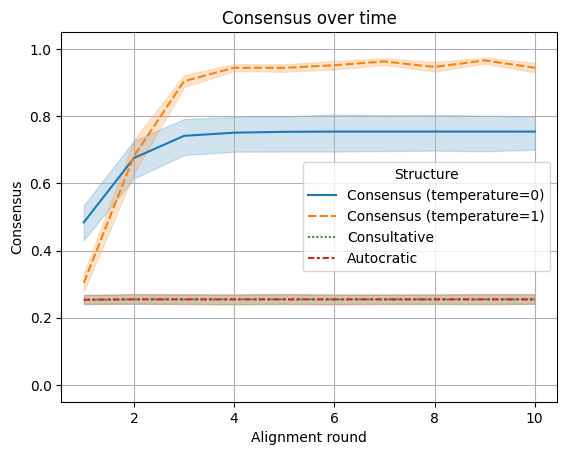

In [ ]:
fig, ax = plt.subplots()

sns.lineplot(
    x="Alignment_round",
    y="Consensus",
    hue="Structure", style="Structure",
    data=df, ax=ax,
    errorbar=("ci", 95),
    # err_style="bars"
)

ax.set_title("Consensus over time")
ax.set_xlabel("Alignment round")
ax.set_ylabel("Consensus")
ax.set_ylim(-0.05, 1.05)
# ax.axhline(y=model.consensus_threshold, color="red", linestyle="--")
ax.grid()
plt.show()